# Laboratorio: Minería de Datos — Regresión Lineal Múltiple
**Metodología:** CRISP-DM  
**Modelo:** `sklearn.linear_model.LinearRegression`  
**Ejercicio:** Predicción de Niveles de Glucosa

In [1]:
# ─────────────────────────────────────────────
# IMPORTS GLOBALES
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Estilo global de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

---
# EJERCICIO 2 — Predicción de Niveles de Glucosa
**Dataset:** `glucosa_data.csv`  
**Variable dependiente:** `Nivel_Glucosa` (mg/dL)  
**Predictores:** `Edad`, `IMC`, `Actividad_Fisica`

## Fase 1 — Business Understanding
El nivel de glucosa en sangre es un indicador clave de la salud metabólica.
Predecirlo a partir de variables clínicas simples (edad, IMC, actividad física) 
permite identificar pacientes en riesgo de diabetes sin necesidad de exámenes complejos.

In [10]:
# ─────────────────────────────────────────────
# Fase 2 — DATA UNDERSTANDING
# ─────────────────────────────────────────────
df_glucosa = pd.read_csv('glucosa_data.csv')

print('Shape:', df_glucosa.shape)
print('\nPrimeras filas:')
display(df_glucosa.head())

print('\nEstadísticas descriptivas:')
display(df_glucosa.describe())

print('\nValores nulos:')
print(df_glucosa.isnull().sum())

Shape: (2000, 4)

Primeras filas:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
0,42,13.466414,1,141.840332
1,67,23.455602,1,171.937432
2,71,25.765184,8,155.504232
3,48,24.079550,2,115.865231
4,35,24.426649,7,115.698730



Estadísticas descriptivas:


,Edad,IMC,Actividad_Fisica,Nivel_Glucosa
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.157000,24.963329,4.664500,139.630129
std,17.544494,3.983588,2.912247,27.342945
min,20.000000,10.586717,0.000000,43.415924
25%,34.000000,22.344522,2.000000,119.067583
50%,50.000000,25.028701,5.000000,139.967314
75%,64.000000,27.751081,7.000000,159.208487
max,79.000000,39.430227,9.000000,227.560693



Valores nulos:
Edad                0
IMC                 0
Actividad_Fisica    0
Nivel_Glucosa       0
dtype: int64


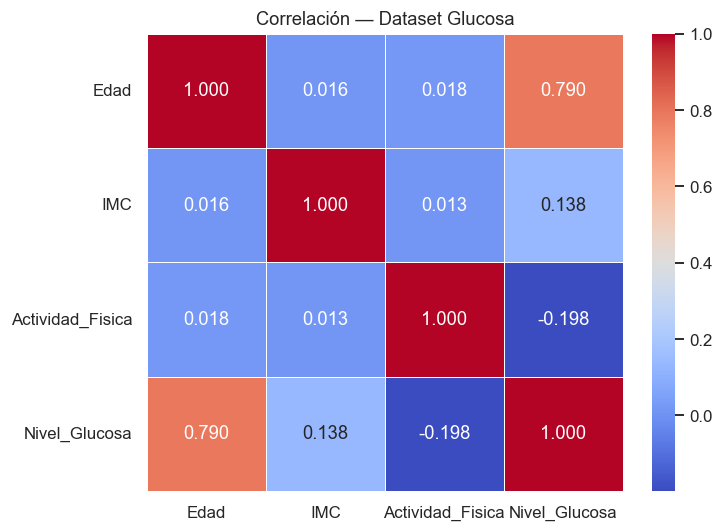

In [11]:
# ─────────────────────────────────────────────
# Fase 2 — Matriz de correlación
# ─────────────────────────────────────────────
plt.figure(figsize=(7, 5))
sns.heatmap(df_glucosa.corr(), annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlación — Dataset Glucosa')
plt.tight_layout()
plt.show()

## Fase 3 — Limpieza de Datos
Aplicamos el proceso de limpieza correspondiente para asegurar la calidad de los datos antes del modelado.

In [ ]:
# ─────────────────────────────────────────────
# Fase 3 — Limpieza de Datos (Avanzada)
# ─────────────────────────────────────────────
print(f'Filas iniciales: {len(df_glucosa)}')

# 1. Estandarizar nombres de columnas (eliminar espacios en blanco)
df_glucosa.columns = df_glucosa.columns.str.strip()

# 2. Identificar y eliminar valores nulos (NaN)
nulos_iniciales = df_glucosa.isnull().sum().sum()
df_glucosa = df_glucosa.dropna()
print(f'Valores nulos eliminados: {nulos_iniciales}')

# 3. Identificar y eliminar registros duplicados
duplicados = df_glucosa.duplicated().sum()
df_glucosa = df_glucosa.drop_duplicates()
print(f'Duplicados eliminados: {duplicados}')

# 4. Estandarizar tipos de datos (asegurar que las columnas sean numéricas)
for col in df_glucosa.columns:
    df_glucosa[col] = pd.to_numeric(df_glucosa[col], errors='coerce')
df_glucosa = df_glucosa.dropna()  # Eliminar si se generaron nuevos nulos por conversión

# 5. Detección y manejo de valores atípicos (Outliers) con el método IQR
Q1 = df_glucosa.quantile(0.25)
Q3 = df_glucosa.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
condicion_outliers = ~((df_glucosa < limite_inferior) | (df_glucosa > limite_superior)).any(axis=1)
filas_antes_outliers = len(df_glucosa)
df_glucosa = df_glucosa[condicion_outliers]
print(f'Valores atípicos (outliers) eliminados: {filas_antes_outliers - len(df_glucosa)}')

# 6. Estandarizar el formato numérico (redondear a 4 decimales)
cols_float = df_glucosa.select_dtypes(include=['float64']).columns
df_glucosa[cols_float] = df_glucosa[cols_float].round(4)

print(f'Filas finales tras limpieza: {len(df_glucosa)}')
display(df_glucosa.head())


In [12]:
# ─────────────────────────────────────────────
# Fase 3 — DATA PREPARATION
# División train/test 80/20
# ─────────────────────────────────────────────
X2 = df_glucosa[['Edad', 'IMC', 'Actividad_Fisica']]
y2 = df_glucosa['Nivel_Glucosa']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print(f'Train: {X2_train.shape[0]} filas | Test: {X2_test.shape[0]} filas')

Train: 1600 filas | Test: 400 filas


In [13]:
# ─────────────────────────────────────────────
# Fase 4 — MODELING
# ─────────────────────────────────────────────
modelo_glucosa = LinearRegression()
modelo_glucosa.fit(X2_train, y2_train)

print('Intercepto (β₀):', round(modelo_glucosa.intercept_, 4))
print('\nCoeficientes:')
coef_df2 = pd.DataFrame({
    'Variable': X2.columns,
    'Coeficiente': modelo_glucosa.coef_,
    'Abs_Coef': np.abs(modelo_glucosa.coef_)
}).sort_values('Abs_Coef', ascending=False)
display(coef_df2)

Intercepto (β₀): 65.8609

Coeficientes:


,Variable,Coeficiente,Abs_Coef
2,Actividad_Fisica,-2.085276,2.085276
0,Edad,1.226590,1.226590
1,IMC,0.933373,0.933373


### Interpretación de coeficientes — Ejercicio 2

| Variable | Coeficiente | Interpretación |
|---|---|---|
| `Edad` | β₁ | Por cada año adicional de edad, el nivel de glucosa **aumenta en β₁ mg/dL** (el metabolismo glucídico empeora con la edad) |
| `IMC` | β₂ | Un punto más de IMC eleva la glucosa en β₂ mg/dL (el exceso de grasa corporal reduce la sensibilidad a la insulina) |
| `Actividad_Fisica` | β₃ | Cada hora semanal adicional de ejercicio **reduce** la glucosa en |β₃| mg/dL (efecto protector del ejercicio) |

> La variable con **mayor valor absoluto de coeficiente** es la de mayor impacto. Observar la tabla `coef_df2` para determinar cuál domina.

In [14]:
# ─────────────────────────────────────────────
# Fase 5 — EVALUATION
# ─────────────────────────────────────────────
y2_pred = modelo_glucosa.predict(X2_test)

mse2  = mean_squared_error(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)
r2_2  = r2_score(y2_test, y2_pred)

print('═══ DESEMPEÑO DEL MODELO — GLUCOSA ═══')
print(f'MSE  : {mse2:.4f}')
print(f'RMSE : {rmse2:.4f}  (en mg/dL)')
print(f'R²   : {r2_2:.4f}')

═══ DESEMPEÑO DEL MODELO — GLUCOSA ═══
MSE  : 233.6930
RMSE : 15.2870  (en mg/dL)
R²   : 0.6814


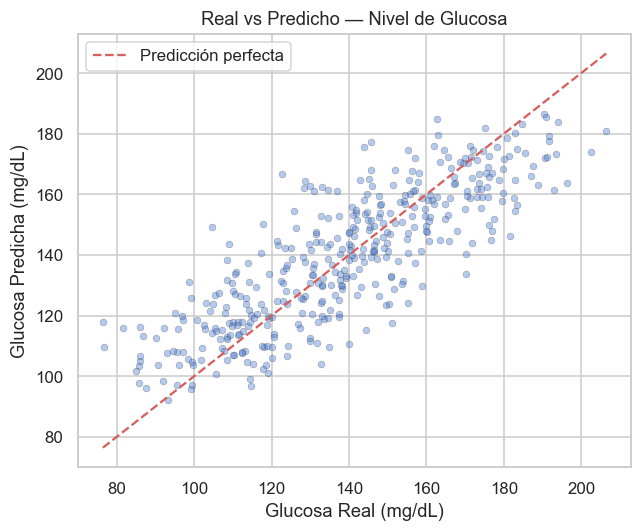

In [15]:
# ─────────────────────────────────────────────
# Fase 5 — Gráfica: Predicho vs Real
# ─────────────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(y2_test, y2_pred, alpha=0.4, edgecolors='k', linewidth=0.3, s=20)
lims = [min(y2_test.min(), y2_pred.min()), max(y2_test.max(), y2_pred.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Glucosa Real (mg/dL)')
plt.ylabel('Glucosa Predicha (mg/dL)')
plt.title('Real vs Predicho — Nivel de Glucosa')
plt.legend()
plt.tight_layout()
plt.show()

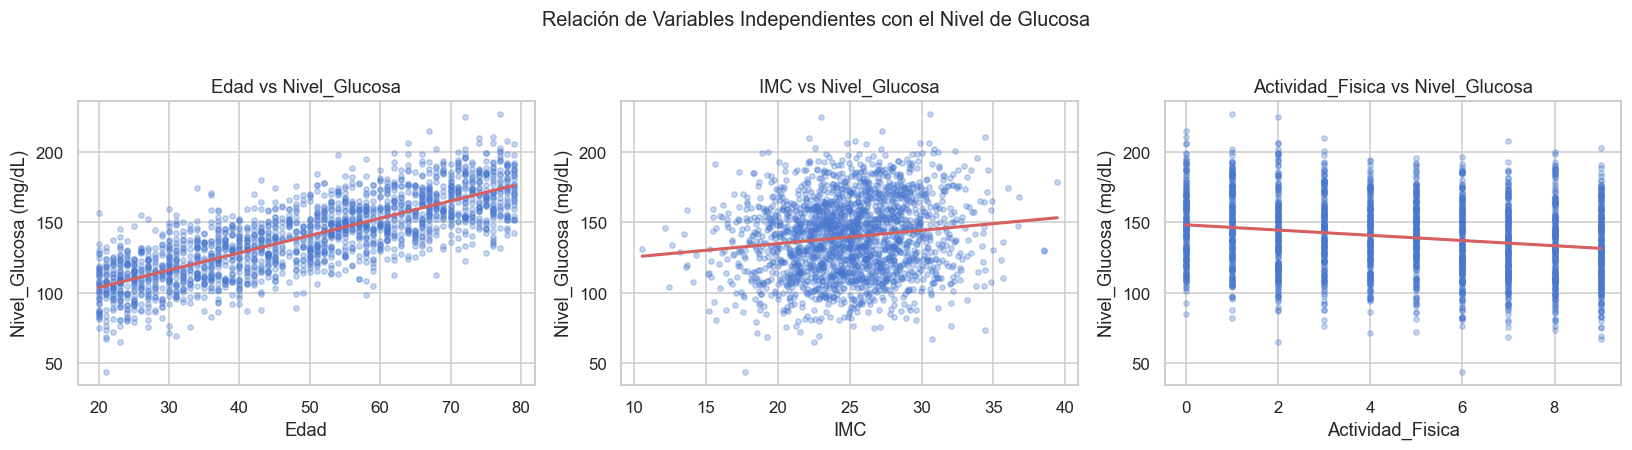

In [16]:
# ─────────────────────────────────────────────
# Fase 5 — Visualización: relación de cada predictor con Nivel_Glucosa
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
predictores2 = ['Edad', 'IMC', 'Actividad_Fisica']

for ax, col in zip(axes, predictores2):
    ax.scatter(df_glucosa[col], df_glucosa['Nivel_Glucosa'], alpha=0.3, s=12)
    m, b = np.polyfit(df_glucosa[col], df_glucosa['Nivel_Glucosa'], 1)
    x_line = np.linspace(df_glucosa[col].min(), df_glucosa[col].max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Nivel_Glucosa (mg/dL)')
    ax.set_title(f'{col} vs Nivel_Glucosa')

plt.suptitle('Relación de Variables Independientes con el Nivel de Glucosa', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Variables ordenadas por impacto (coeficientes estandarizados):


,Variable,Coef_Estandarizado
0,Edad,21.570811
2,Actividad_Fisica,-6.106122
1,IMC,3.722529


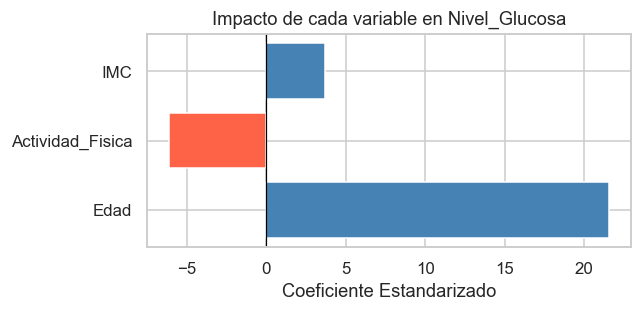

In [17]:
# ─────────────────────────────────────────────
# Análisis de importancia de variables
# Usamos coeficientes estandarizados para comparar "manzanas con manzanas"
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2_train)
modelo_glucosa_std = LinearRegression()
modelo_glucosa_std.fit(X2_scaled, y2_train)

importancia2 = pd.DataFrame({
    'Variable': X2.columns,
    'Coef_Estandarizado': modelo_glucosa_std.coef_
}).assign(Abs=lambda d: d['Coef_Estandarizado'].abs())\
  .sort_values('Abs', ascending=False)

print('Variables ordenadas por impacto (coeficientes estandarizados):')
display(importancia2.drop(columns='Abs'))

# Barplot de importancia
plt.figure(figsize=(6, 3))
colors = ['steelblue' if c > 0 else 'tomato' for c in importancia2['Coef_Estandarizado']]
plt.barh(importancia2['Variable'], importancia2['Coef_Estandarizado'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente Estandarizado')
plt.title('Impacto de cada variable en Nivel_Glucosa')
plt.tight_layout()
plt.show()

In [18]:
# Exportar modelo de glucosa
joblib.dump(modelo_glucosa, 'modelo_glucosa.pkl')
print('Modelo guardado como: modelo_glucosa.pkl')

# Verificación
modelo_glc = joblib.load('modelo_glucosa.pkl')
test_pred2 = modelo_glc.predict([[45, 25.0, 3]])
print(f'Predicción de prueba (Edad=45, IMC=25, Act=3h): {test_pred2[0]:.2f} mg/dL')

Modelo guardado como: modelo_glucosa.pkl
Predicción de prueba (Edad=45, IMC=25, Act=3h): 138.14 mg/dL
